✅ Saved figure: Tripartite_Phyto_Gene_GOBP_300dpi.png
✅ Saved: edges_phytochemical_gene.csv, edges_gene_biological_process.csv
✅ Gene→BP edges found (after filtering): 12
✅ Collapsed into bucket (when same phytochemical-set matched):


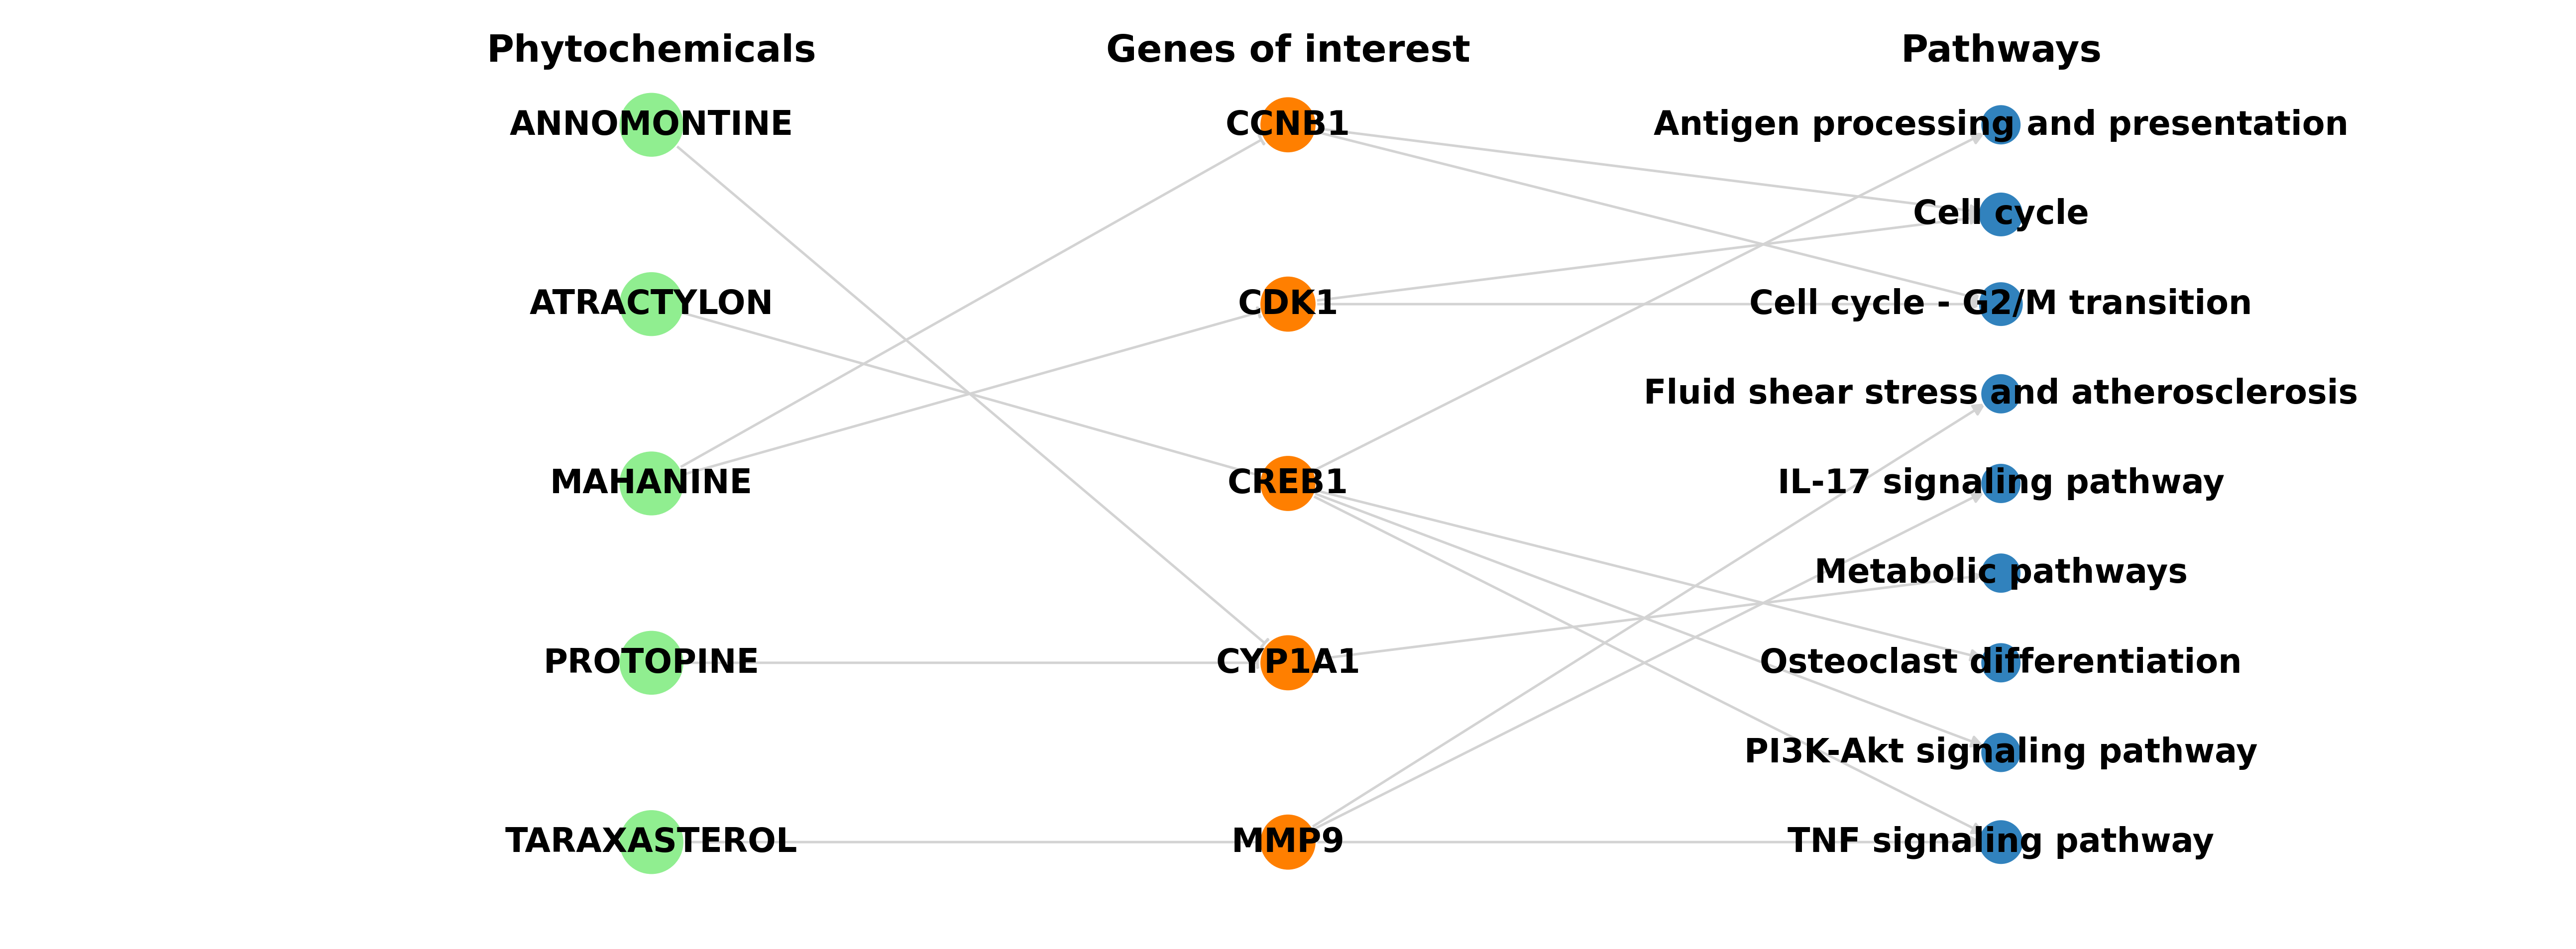

In [ ]:
# Tripartite network: Phytochemicals → Genes → Biological Processes (GO BP modules)
# - Reads EnrichmentMap TSV (Genes pipe-separated + GS_DESCR)
# - Keeps only your genes of interest
# - Removes selected BP terms
# - COLLAPSES specified "transcription/RNA/metabolism regulation" terms into ONE bucket
#   * BUT ONLY when the bucket would be reached by the SAME phytochemical(s)
# - BP names UNSPLIT (single-line)
# - Fixes bottom clipping by using axis-fraction positions (so nodes always fit)
# - Draws 3-column network
# - Exports edge lists for Cytoscape

import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.lines import Line2D
from collections import defaultdict
import io # Added for reading string data

# Define the new input data as a string
# NOTE: The following 10 gene-pathway edges were removed after a literature review
# found no direct psoriasis-relevant evidence for them (see rationale below the
# script). PTGS2/Tricin/Tamarixetin were already removed in an earlier revision.
#
# Removed edges (generic KEGG/pathway-membership artifacts, not psoriasis-specific):
#   Mahanine   - CCNB1  - Oocyte meiosis
#   Mahanine   - CCNB1  - Progesterone-mediated oocyte maturation
#   Mahanine   - CDK1   - Oocyte meiosis
#   Mahanine   - CDK1   - Progesterone-mediated oocyte maturation
#   Atractylon - CREB1  - Aldosterone synthesis and secretion
#   Atractylon - CREB1  - Longevity regulating pathway
#   Atractylon - CREB1  - Renin secretion
#   CYP1A1 (Protopine & Annomontine) - Metabolic pathways
#   CYP1A1 (Protopine & Annomontine) - Ovarian steroidogenesis
#   Taraxasterol - MMP9 - Endocrine resistance
new_data_str = """Phytochemical	GeneSymbol	PathwayName
Mahanine	CCNB1	Cell cycle
Mahanine	CCNB1	Cell cycle - G2/M transition
Mahanine	CCNB1	FoxO signaling pathway
Mahanine	CCNB1	p53 signaling pathway
Mahanine	CDK1	Cell cycle
Mahanine	CDK1	Cell cycle - G2/M transition
Mahanine	CDK1	p53 signaling pathway
Atractylon	CREB1	AMPK signaling pathway
Atractylon	CREB1	Antigen processing and presentation
Atractylon	CREB1	cAMP signaling pathway
Atractylon	CREB1	Estrogen signaling pathway
Atractylon	CREB1	Insulin resistance
Atractylon	CREB1	Osteoclast differentiation
Atractylon	CREB1	PI3K-Akt signaling pathway
Atractylon	CREB1	TNF signaling pathway
Protopine & Annomontine	CYP1A1	Metabolism of xenobiotics by cytochrome P450
Protopine & Annomontine	CYP1A1	Retinol metabolism
Protopine & Annomontine	CYP1A1	Tryptophan metabolism
Taraxasterol	MMP9	Estrogen signaling pathway
Taraxasterol	MMP9	Fluid shear stress and atherosclerosis
Taraxasterol	MMP9	IL-17 signaling pathway
Taraxasterol	MMP9	TNF signaling pathway
Protopine & Annomontine	CYP1A1	Metabolic pathways"""

# -----------------------------
# 1) INPUTS
# -----------------------------
# Read the data from the string into a DataFrame instead of a file
df = pd.read_csv(io.StringIO(new_data_str), sep="\t")

# Derive chem_gene_edges from the new DataFrame
new_chem_gene_edges_list = []
for _, row in df.iterrows():
    phytos = [p.strip() for p in row["Phytochemical"].split(" & ") if p.strip()]
    gene = row["GeneSymbol"]
    for phyto in phytos:
        new_chem_gene_edges_list.append((phyto, gene))
chem_gene_edges = sorted(list(set(new_chem_gene_edges_list)))

genes_of_interest = sorted({g for _, g in chem_gene_edges})

# -----------------------------
# ALLOW only specific BP terms (keep in the plot)
# -----------------------------
ALLOWED_BPS = {
    "IL-17 signaling pathway",
    "TNF signaling pathway",
    "NF-kappa B signaling pathway",
    "PI3K-Akt signaling pathway",
    "VEGF signaling pathway",
    "Cell cycle",
    "Cell cycle - G2/M transition",
    "Antigen processing and presentation",
    "Osteoclast differentiation",
    "Fluid shear stress and atherosclerosis",
    "Metabolic pathways"
}

# -----------------------------
# COLLAPSE LIST (lowercase keys) - Removed as per user request to only keep specific pathways
# -----------------------------
# COLLAPSE_TO_BUCKET = {
#     "transcription by rna polymerase ii",
#     "regulation of transcription by rna polymerase ii",
#     "dna-templated transcription",
#     "regulation of dna-templated transcription",
#     "nucleic acid metabolic process",
#     "nucleobase-containing compound metabolic process",
#     "nucleic acid biosynthetic process",
#     "nucleobase-containing compound biosynthetic process",
#     "regulation of rna metabolic process",
#     "rna metabolic process",
#     "rna biosynthetic process",
#     "regulation of rna biosynthetic process",
#     "regulation of nucleobase-containing compound metabolic process",
#     "regulation of macromolecule metabolic process",
#     "positive regulation of macromolecule metabolic process",
#     "positive regulation of nucleobase-containing compound metabolic process",
#     "positive regulation of biosynthetic process",
#     "regulation of primary metabolic process",
# }
# BUCKET_LABEL = "Transcription/RNA regulation"

# -----------------------------
# 2) Build Gene → BP edges for ONLY genes of interest from the new DataFrame
# -----------------------------

# Column names from the input data
col_genes = "GeneSymbol"
col_term  = "PathwayName"

raw_gene_bp_edges = []
for _, row in df.iterrows():
    term_raw = str(row[col_term]).strip()

    # Keep only allowed BP terms
    if term_raw not in ALLOWED_BPS:
        continue

    # The GeneSymbol column already contains the gene
    gene = str(row[col_genes]).strip()

    for phyto_gene_tuple in chem_gene_edges:
      if gene == phyto_gene_tuple[1] and gene in genes_of_interest:
          raw_gene_bp_edges.append((gene, term_raw))
          break # Only add once for each gene-term pair

raw_gene_bp_edges = sorted(set(raw_gene_bp_edges))

if len(raw_gene_bp_edges) == 0:
    raise ValueError(
        "❌ No Gene→BP edges found. Check:\n"
        "1) The genes are SYMBOLS\n"
        "2) The genes of interest exist in the BP gene lists\n"
        "3) The pathways match the ALLOWED_BPS list"
    )

# -----------------------------
# 3) Collapse logic (only within same phytochemical-set) - Removed as per user request to only keep specific pathways
# -----------------------------
gene_bp_edges = raw_gene_bp_edges # No collapsing applied

# -----------------------------
# 4) Build directed graph
# -----------------------------
G = nx.DiGraph()

chemicals = sorted({c for c, _ in chem_gene_edges})
genes     = sorted({g for _, g in chem_gene_edges})
bps       = sorted({bp for _, bp in gene_bp_edges})

G.add_nodes_from(chemicals, layer="Phytochemical")
G.add_nodes_from(genes,      layer="Gene")
G.add_nodes_from(bps,        layer="BiologicalProcess")

G.add_edges_from(chem_gene_edges)
G.add_edges_from(gene_bp_edges)

# -----------------------------
# 5) Column layout (USE axis-fraction range 0..1 to avoid bottom cut)
# -----------------------------
def column_positions_axis_fraction(items, x_value, top=0.92, bottom=0.08):
    """
    Places nodes evenly between [bottom, top] in axis-fraction coordinates.
    This prevents bottom/top clipping regardless of font size.
    """
    n = len(items)
    if n == 1:
        ys = [(top + bottom) / 2]
    else:
        ys = np.linspace(top, bottom, n)
    return {item: (x_value, y) for item, y in zip(items, ys)}

pos = {}
pos.update(column_positions_axis_fraction(chemicals, x_value=0.25, top=0.88, bottom=0.10))
pos.update(column_positions_axis_fraction(genes,      x_value=0.50, top=0.88, bottom=0.10))
pos.update(column_positions_axis_fraction(bps,        x_value=0.78, top=0.88, bottom=0.10))

# -----------------------------
# 6) Styling
# -----------------------------
color_map = {
    "Phytochemical": "#90EE90",
    "Gene":          "#ff7f00",
    "BiologicalProcess": "#3182bd",
}
node_colors = [color_map[G.nodes[n]["layer"]] for n in G.nodes()]

node_sizes = []
for n in G.nodes():
    layer = G.nodes[n]["layer"]
    if layer == "Phytochemical":
        node_sizes.append(1000)
    elif layer == "Gene":
        node_sizes.append(750)
    else:
        node_sizes.append(300 + 90 * G.in_degree(n))

# -----------------------------
# 7) Draw
# -----------------------------
fig_w, fig_h = 22, 8
fig, ax = plt.subplots(figsize=(fig_w, fig_h), dpi=300)

nx.draw_networkx_nodes(
    G, pos,
    node_size=node_sizes,
    node_color=node_colors,
    edgecolors="white",
    linewidths=0.8,
    ax=ax
)

nx.draw_networkx_edges(
    G, pos,
    edge_color="#d3d3d3",
    width=1.2,
    arrows=True,
    arrowstyle="-|>",
    arrowsize=12,
    connectionstyle="arc3,rad=0.0",
    ax=ax
)

# Labels (CENTER aligned as you want)
labels = {n: (n.upper() if G.nodes[n]["layer"] == "Phytochemical" else n) for n in G.nodes()}

nx.draw_networkx_labels(
    G, pos, labels=labels,
    font_size=16, font_weight="bold",
    horizontalalignment="center",
    verticalalignment="center",
    ax=ax
)

# Column headers
ax.text(0.25, 0.98, "Phytochemicals", ha="center", va="top",
        fontsize=18, fontweight="bold", transform=ax.transAxes)
ax.text(0.50, 0.98, "Genes of interest", ha="center", va="top",
        fontsize=18, fontweight="bold", transform=ax.transAxes)
ax.text(0.78, 0.98, "Pathways", ha="center", va="top",
        fontsize=18, fontweight="bold", transform=ax.transAxes)

# Legend - REMOVED as per user request
# legend_handles = [
#     Line2D([0], [0], marker='o', color='w', label='Phytochemical',
#            markerfacecolor=color_map["Phytochemical"], markersize=10),
#     Line2D([0], [0], marker='o', color='w', label='Gene',
#            markerfacecolor=color_map["Gene"], markersize=10),
#     Line2D([0], [0], marker='o', color='w', label='Biological process',
#            markerfacecolor=color_map["BiologicalProcess"], markersize=10),
# ]
# ax.legend(handles=legend_handles, loc="lower left", frameon=False, fontsize=11)

ax.set_axis_off()

# IMPORTANT: lock axes to [0,1] because we used axis-fraction coordinates
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

# Save with padding so nothing clips
out_png = "Tripartite_Phyto_Gene_GOBP_300dpi.png"
plt.savefig(out_png, dpi=300, bbox_inches="tight", pad_inches=0.8)
print(f"✅ Saved figure: {out_png}")

# -----------------------------
# 8) Export edge lists (Cytoscape-ready)
# -----------------------------
pd.DataFrame(chem_gene_edges, columns=["source_phytochemical", "target_gene"]) \
  .to_csv("edges_phytochemical_gene.csv", index=False)

pd.DataFrame(gene_bp_edges, columns=["source_gene", "target_biological_process"]) \
  .to_csv("edges_gene_biological_process.csv", index=False)

print("✅ Saved: edges_phytochemical_gene.csv, edges_gene_biological_process.csv")
print(f"✅ Gene→BP edges found (after filtering): {len(gene_bp_edges)}")
print("✅ Collapsed into bucket (when same phytochemical-set matched):" ) # Collapsing logic removed
